# Datetime variables

[Feature Engineering for Machine Learning Course](https://www.trainindata.com/p/feature-engineering-for-machine-learning)

Datetime variables take dates and / or time as values. For example, date of birth ('29-08-1987', '12-01-2012'), or date of application ('2016-Dec', '2013-March'). Datetime variables can contain dates only, times only, or dates and time.

We don't use datetime variables straightaway in machine learning because:

- They contain a huge number of different values.
- We can extract much more information from datetime variables by preprocessing them correctly.

Furthermore, date variables frequently include dates that were absent from the dataset used to train the machine learning model. In fact, date variables are frequently used to store dates that are in the future in comparison to the dates in the training dataset. As a result, because they were never seen while being trained, the machine learning model will have no idea what to do with the new values.

=============================================================================

## In this demo: Peer-to-peer lending (Finance)

In this demo, we will use a toy data set that simulates data from a peer-to-peer finance company.

To obtain the data, go to the lecture **Download datasets** in **Section 2**. This is a toy dataset that I created and comes within the Datasets.zip file that you can find in this lecture.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Let's load the dataset.

# Variable definitions:
#-------------------------
# disbursed amount: loan amount lent to the borrower
# market: risk band in which borrowers are placed
# date_issued: date the loan was issued
# date_last_payment: date of last payment towards repyaing the loan

data = pd.read_csv('../Datasets/loan.csv')

data.columns

Index(['customer_id', 'disbursed_amount', 'interest', 'market', 'employment',
       'time_employed', 'householder', 'income', 'date_issued', 'target',
       'loan_purpose', 'number_open_accounts', 'date_last_payment',
       'number_credit_lines_12'],
      dtype='str')

In [5]:
# Pandas assigns type 'object' to dates 
# when loading from csv.

# Let's have a look:

data[['date_issued', 'date_last_payment']].dtypes

date_issued          str
date_last_payment    str
dtype: object

Both **date_issued** and **date_last_payment** are cast as objects. Therefore, pandas will treat them as strings.

To tell pandas that they are datetime variables, we need to re-cast them into datetime format.

In [6]:
# Let's parse the dates into datetime format.
# This will allow us to make some analysis afterwards.

data['date_issued_dt'] = pd.to_datetime(data['date_issued'])
data['date_last_payment_dt'] = pd.to_datetime(data['date_last_payment'])

data[['date_issued', 'date_issued_dt', 'date_last_payment', 'date_last_payment_dt']].head()

,date_issued,date_issued_dt,date_last_payment,date_last_payment_dt
0,2013-06-11,2013-06-11,2016-01-14,2016-01-14
1,2014-05-08,2014-05-08,2016-01-25,2016-01-25
2,2013-10-26,2013-10-26,2014-09-26,2014-09-26
3,2015-08-20,2015-08-20,2016-01-26,2016-01-26
4,2014-07-22,2014-07-22,2016-01-11,2016-01-11


In [7]:
# Let's extract the month and the year from the 
# datetime variable to make plots.

data['month'] = data['date_issued_dt'].dt.month
data['year'] = data['date_issued_dt'].dt.year

market               A           B           C           D           E
year month                                                            
2007 7         1820.00         NaN         NaN         NaN         NaN
     8             NaN         NaN         NaN         NaN    18600.00
     9             NaN         NaN         NaN         NaN    19432.25
     10            NaN         NaN         NaN         NaN    14256.00
     12            NaN     2796.50         NaN         NaN         NaN
...                ...         ...         ...         ...         ...
2015 8      1149909.75  1536688.75  1491727.50   880038.75   852688.00
     9       757929.75  1287596.50  1386275.50   879593.25   686892.25
     10      971295.50  2361789.00  2243754.50  1080193.75  1112724.25
     11      998115.50  1679571.50  2017138.00   858076.25   542300.00
     12     1094781.50  1775188.00  1941545.75  1083162.50   871467.50

[99 rows x 5 columns]


Text(0, 0.5, 'Disbursed Amount')

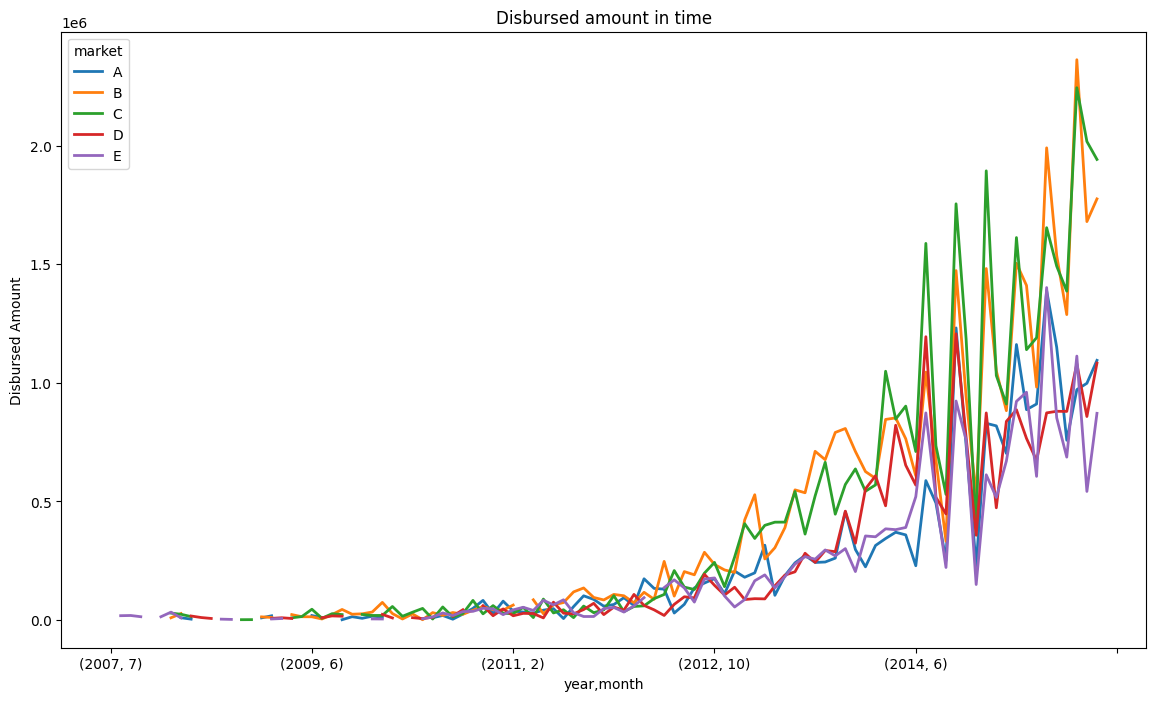

In [12]:
# Let's see how much money has been disbursed
# over the years to the different risk
# markets (grade variable).

fig = (fig_data := data.groupby(['year', 'month', 'market'])['disbursed_amount'].sum().unstack()).plot(
    figsize=(14, 8), linewidth=2)

print(fig_data)

fig.set_title('Disbursed amount in time')
fig.set_ylabel('Disbursed Amount')

This toy finance company seems to have increased the amount of money lent from 2012 onwards. The tendency indicates that they will continue to grow. In addition, we can see that their major business comes from lending money to C and B-grade borrowers.

A grades are given to the lowest-risk borrowers; these are the borrowers who are most likely to repay their loans because they are in a better financial situation. Borrowers within this grade are charged lower interest rates.

Riskier borrowers represent the D and E grades. Borrowers who are in a slightly tighter financial situation or who do not have enough financial history to make a reliable credit assessment. They are typically charged higher rates, as the business, and therefore the investors, take a higher risk when lending them money.

**That is all for this demonstration. I hope you enjoyed the notebook, and I'll see you in the next one.**